In [1]:
#нужно сделать предикт c 1 мая 25 года по 31 мая 25 года 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from sklearn.preprocessing import MinMaxScaler
import datetime as dt

In [4]:
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from datetime import datetime
from pmdarima.arima import auto_arima
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error

In [6]:
import keras
from keras.layers import Flatten, Dense,GRU, LSTM, RNN
from keras.models import Sequential
from tensorflow.keras import layers
from sklearn.preprocessing import MinMaxScaler

In [7]:
dataset = pd.read_csv('/home/pavel/Загрузки/Telegram Desktop/btcusd_1-min_data.csv')

In [8]:
df = dataset.copy()

In [9]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'], unit='s')

In [10]:
df['year'] = df['Timestamp'].dt.year
df['month'] = df['Timestamp'].dt.month
df['day'] = df['Timestamp'].dt.day
df['hour'] = df['Timestamp'].dt.hour
df['minute'] = df['Timestamp'].dt.minute

In [47]:
df

,Timestamp,Open,High,Low,Close,Volume,year,month,day,hour,minute
0,2012-01-01 10:01:00,4.58,4.58,4.58,4.58,0.000000,2012,1,1,10,1
1,2012-01-01 10:02:00,4.58,4.58,4.58,4.58,0.000000,2012,1,1,10,2
2,2012-01-01 10:03:00,4.58,4.58,4.58,4.58,0.000000,2012,1,1,10,3
3,2012-01-01 10:04:00,4.58,4.58,4.58,4.58,0.000000,2012,1,1,10,4
4,2012-01-01 10:05:00,4.58,4.58,4.58,4.58,0.000000,2012,1,1,10,5
...,...,...,...,...,...,...,...,...,...,...,...
7490559,2026-03-31 00:00:00,66741.00,66755.00,66656.00,66656.00,1.177769,2026,3,31,0,0
7490560,2026-03-31 00:01:00,66674.00,66690.00,66647.00,66690.00,0.544930,2026,3,31,0,1
7490561,2026-03-31 00:02:00,66684.00,66729.00,66668.00,66680.00,0.530529,2026,3,31,0,2
7490562,2026-03-31 00:03:00,66680.00,66690.00,66674.00,66674.00,0.594485,2026,3,31,0,3


In [63]:
day = df['day']
month = df['month']
year = df['year']
hour = df['hour']
minute = df['minute']

In [64]:
date = df[(year >= 2022) & (year <= 2025) & (day >= 1) & (month >= 1) & (hour == 0) & (minute == 0)]

In [14]:
date1 = df[(year >= 2022) & (year <= 2025) & (day >= 1) & (month >= 1) & (hour == 0) & (minute == 0)]

In [65]:
drop_col = ['hour', 'minute']
date = date.drop(columns = drop_col)

In [66]:
df_date = date.columns[0]
date = date.set_index(df_date)

In [68]:
day = date['day']
month = date['month']
year = date['year']
date = date[(year <= 2025) & (month <= 4) & (day <= 30)]

In [23]:
day = date1['day']
month = date1['month']
year = date1['year']
date1 = date1[(year == 2025) & (month == 5) & (day <= 31)]

In [36]:
predict_date = date1.index

In [33]:
decompose_open = seasonal_decompose(date['Open'], model = 'additive', period = 30)
trend_decompose_open = decompose_open.trend
seasonal_decompose_open = decompose_open.seasonal
reisid_decompose_open = decompose_open.resid
observed_decompose_open = decompose_open.observed

<Figure size 1200x900 with 0 Axes>

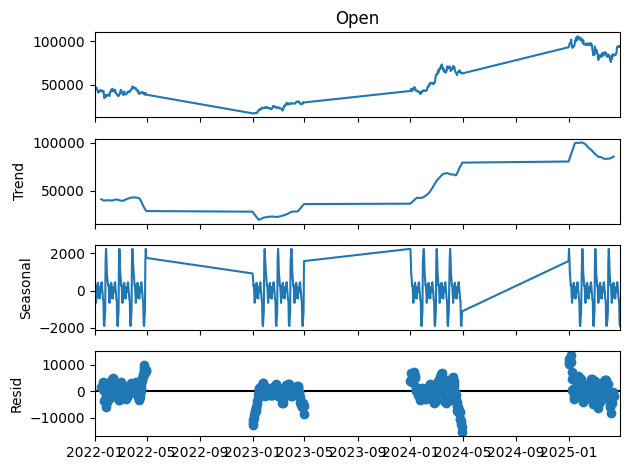

In [34]:
plt.figure(figsize = (12, 9))
decompose_open.plot()
plt.show()

In [35]:
def adfuller_test(dataset, features):
    for feature in dataset[features]:

        name_feature = dataset[feature].name
        result = adfuller(dataset[feature])
        print(f'Произведен тест Дики Фуллера Признака : {name_feature}')
        print('Результат теста:')
        if result[1] > 0.05 :
            print('Ряд не стационарен,нужно делать дифференцирование')
        else:
            print('Ряд стационарен, дифференцирование не нужно')
        print('-' * 38)

In [51]:
columns_test_adfuller = ['Open']

In [52]:
adfuller_test(date, columns_test_adfuller)

Произведен тест Дики Фуллера Признака : Open
Результат теста:
Ряд не стационарен,нужно делать дифференцирование
--------------------------------------


In [40]:
def minmax_scal(dataset):
    dataset = dataset.copy()
    minmax = MinMaxScaler()
    for col in dataset.columns:
        dataset[col] = minmax.fit_transform(dataset[[col]])

    return dataset

In [72]:
df_minmax = minmax_scal(date)

In [74]:
df_minmax

,Open,High,Low,Close,Volume,year,month,day
Timestamp,,,,,,,,
2022-01-01,0.335918,0.335767,0.335134,0.335123,0.066075,0.0,0.0,0.000000
2022-01-02,0.346524,0.346279,0.346524,0.346604,0.002641,0.0,0.0,0.034483
2022-01-03,0.340380,0.340140,0.339477,0.340040,0.056213,0.0,0.0,0.068966
2022-01-04,0.334177,0.333853,0.333756,0.333744,0.001952,0.0,0.0,0.103448
2022-01-05,0.325409,0.325093,0.324813,0.324859,0.061593,0.0,0.0,0.137931
...,...,...,...,...,...,...,...,...
2025-04-26,0.872419,0.871646,0.872184,0.872329,0.002662,1.0,1.0,0.862069
2025-04-27,0.871771,0.871534,0.871771,0.872340,0.001189,1.0,1.0,0.896552
2025-04-28,0.861925,0.861631,0.861914,0.861948,0.002972,1.0,1.0,0.931034


In [23]:
df_minmax.columns

Index(['Open', 'High', 'Low', 'Close', 'Volume', 'year', 'month', 'day'], dtype='object')

In [75]:
columns_drop = ['High', 'Low', 'Close', 'Volume', 'year', 'month', 'day']
df_minmax = df_minmax.drop(columns = columns_drop)

In [76]:
df_minmax['lag1'] = df_minmax['Open'].shift(1)
df_minmax['lag2'] = df_minmax['Open'].shift(2)
df_minmax['lag3'] = df_minmax['Open'].shift(3)
df_minmax['lag7'] = df_minmax['Open'].shift(7)
df_minmax['lag14'] = df_minmax['Open'].shift(14)
df_minmax['lag30'] = df_minmax['Open'].shift(30)
df_minmax = df_minmax.dropna()

In [77]:
split = len(date.loc[:'2025-02-28'])
x_train, x_test = df_minmax[:split].drop(columns = ['Open']), df_minmax[split:].drop(columns = ['Open'])
y_train, y_test = df_minmax['Open'][:split], df_minmax['Open'][split:]

In [78]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(413, 6)
(413,)
(30, 6)
(30,)


In [80]:
def keras_LSTM(x_tr,y_tr, x_tt ):

    
    stopping_ = keras.callbacks.EarlyStopping(
        monitor="mae",
        patience=10,
        mode = 'auto',
        restore_best_weights=True,
        verbose = 1
        
    )
    model = keras.Sequential([
        keras.layers.Input(shape=(x_tr.shape[1], 1)),
        keras.layers.LSTM(64),
        keras.layers.Dense(64,activation = 'relu'),
        keras.layers.Dense(32, activation = 'relu', kernel_regularizer= 'l2'),
        keras.layers.Dense(1)
    ])
    model.compile(optimizer = 'adam', loss = 'mse', metrics = ['mae'])

    history = model.fit(x_tr, y_tr, epochs = 100, batch_size = 32, 
        verbose = 0, callbacks = [stopping_])

    predict= model.predict(x_tt, verbose = 0)

    return model, history ,predict
    
keras_LSTM, history_LSTM ,predict_keras = keras_LSTM(x_train, y_train, x_test)

Epoch 54: early stopping
Restoring model weights from the end of the best epoch: 44.


In [81]:
mae = mean_absolute_error(y_test, predict_keras)
mae

0.023173603284833873

In [82]:
y_train = y_train.to_frame()

In [83]:
def convert_predict_to_df(predict, date_index_actual_data):
    
    pred_df = pd.DataFrame({
        'target' : [i[0] for i in predict]
    })
    pred_df = pred_df.set_index(date_index_actual_data)
    return pred_df

In [84]:
def visual_actual_or_prediction(actual, predict, name_model = '', layers = '' ):
    plt.figure(figsize = (18,8))
    plt.plot(actual.index, actual, 'b', label = 'Истинные данные')
    plt.plot(predict.index, predict, 'r', label = 'Предикит модели')
    plt.plot([actual.index[-1], predict.index[0]],
             [actual.values[-1], predict.values[0]], 'r--')
    plt.title(f'Актуальные данные и данные предикта модели {name_model}, {layers} layers')
    plt.xlabel('Года')
    plt.ylabel('Продажи')
    plt.grid()
    plt.legend(loc = "upper left")
    plt.show()


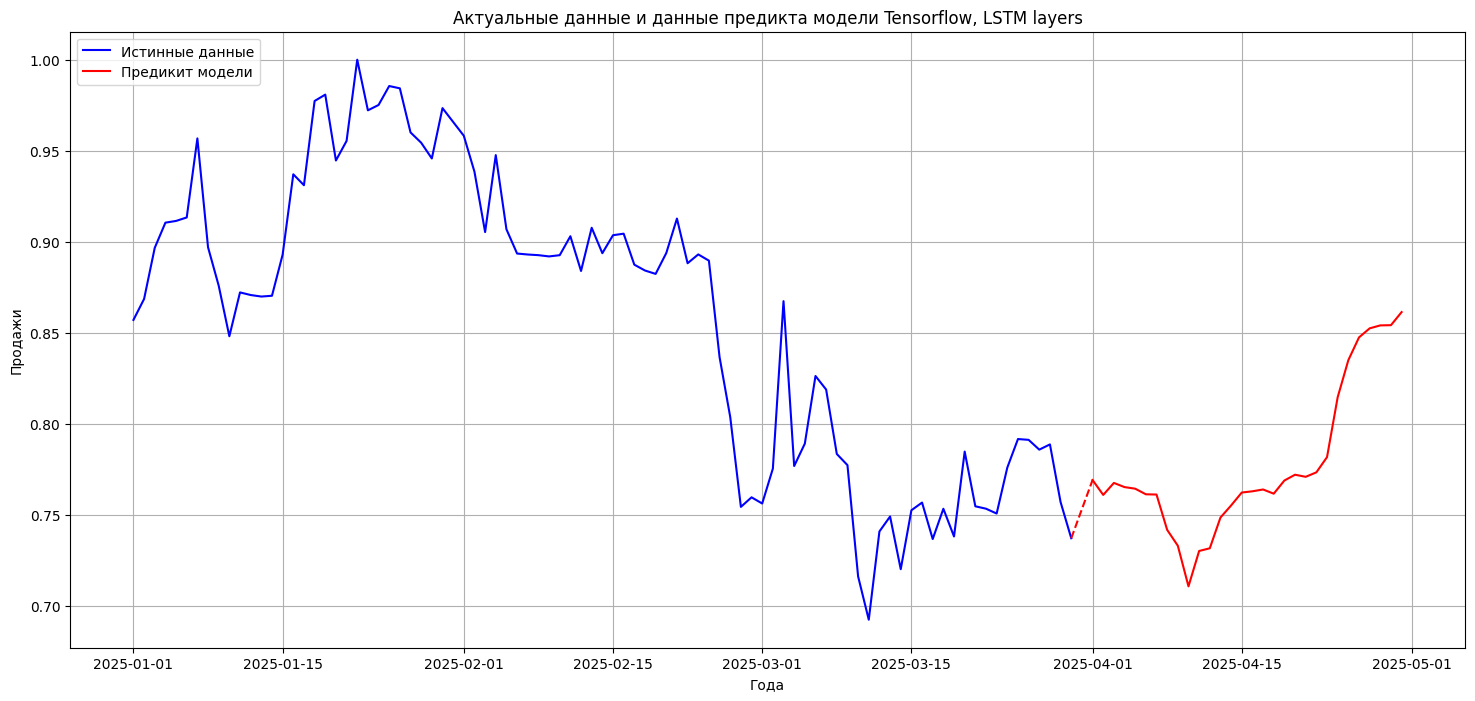

In [137]:
predict_model = convert_predict_to_df(predict_keras, x_test.index)
visual_actual_or_prediction(y_train.loc['2025-01-01':], predict_model , 'Tensorflow', 'LSTM')

In [108]:
aprel_data = predict_model.to_numpy()

In [109]:
pred_mai = []
days_to_predict = 31

for q in range(days_to_predict):
    pred = keras_LSTM.predict(aprel_data)
    pred_value = pred.flatten()[0]
    pred_mai.append(pred_value)
    aprel_data = np.append(aprel_data, pred_value)
    aprel_data = aprel_data[-31:]
    aprel_data = aprel_data.reshape(-1, 1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━

In [138]:
predict_model_mai = convert_predict_to_df(pred_mai, predict_date)


In [136]:
def visual_actual_or_predictionqqq(actual, predict, predict2 , name_model = '', layers = '' ):
    plt.figure(figsize = (18,8))
    plt.plot(actual.index, actual, 'b', label = 'Истинные данные')
    plt.plot(predict.index, predict, 'r', label = 'Предикит модели')
    plt.plot([actual.index[-1], predict.index[0]],
             [actual.values[-1], predict.values[0]], 'r--')
    plt.plot(predict2.index, predict2 , 'g', label = 'Предикт на май')
    plt.plot([predict.index[-1], predict2.index[0]],
            [predict.values[-1], predict2.values[0]])
    plt.title(f'Актуальные данные и данные предикта модели {name_model}, {layers} layers')
    plt.xlabel('Года')
    plt.ylabel('Продажи')
    plt.grid()
    plt.legend(loc = "upper left")
    plt.show()


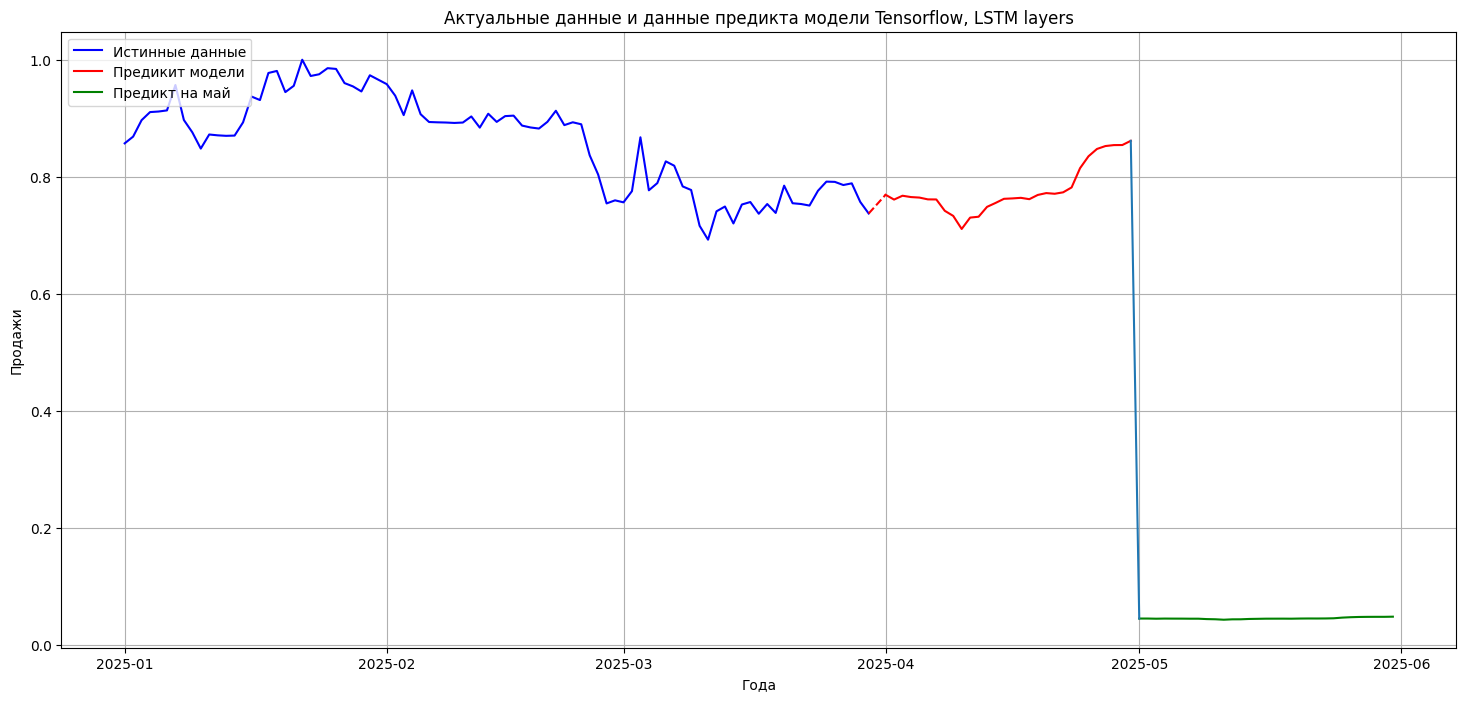

In [139]:
visual_actual_or_predictionqqq(y_train.loc['2025-01-01':], predict_model ,predict_model_mai, 'Tensorflow', 'LSTM')